In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import plotly.express as px
import string
import warnings
warnings.filterwarnings('ignore')



In [2]:
data = pd.read_csv("/Users/syrassaladin/Downloads/WELFake_Dataset.csv")

In [3]:
data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
data.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [5]:
data['text'][0]

'No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.A 2:39 minute clip from the radio show can be heard here. It was provided to Breitbart Texas by someone who would like to be referred to

In [7]:
data['text'][72131]

'Migrants Refuse To Leave Train At Refugee Camp In Hungary\n\nThousands of migrants flooded into a train station in the Hungarian capital Thursday after police lifted a two-day blockade, but some who boarded a train they thought was going to Germany ended up instead at a refugee camp just miles from Budapest.\n\nThe Associated Press reports that "excited migrants piled into a newly arrived train at the Keleti station in Hungary\'s capital despite announcements in Hungarian and English that all services from the station to Western Europe had been canceled. A statement on the main departures board said no more trains to Austria or Germany would depart \'due to safety reasons until further notice!\'\n\n"Many migrants, who couldn\'t understand either language and were receiving no advice from Hungarian officials, scrambled aboard in a standing-room-only crush and hoped for the best," the AP said.\n\nScuffles broke out when police ordered the passengers off the train at Bicske, according to

In [9]:
data.drop('Unnamed: 0',axis=1,inplace=True)
data.info()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   71576 non-null  str  
 1   text    72095 non-null  str  
 2   label   72134 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.7 MB


title    558
text      39
label      0
dtype: int64

In [11]:
data.fillna(' ', inplace=True)
features = data[['title', 'text']]
labels = data['label']

In [12]:
data.isnull().sum()


title    0
text     0
label    0
dtype: int64

In [15]:
label_Status = data['label'].value_counts()
transactions = label_Status.index
quantity = label_Status.values

figure = px.pie(
    values=quantity,
    names=transactions,
    title="Fake vs Real News",
    hole=0.3
)
figure.show()

In [17]:
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

fake_text = ' '.join(data[data['label'] == 0]['text']) #fake
real_text = ' '.join(data[data['label'] == 1]['text']) #good


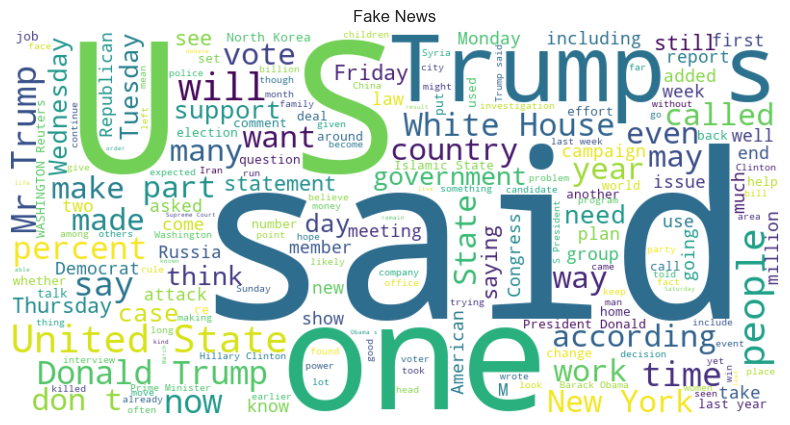

In [18]:
plot_wordcloud(fake_text, 'Fake News')

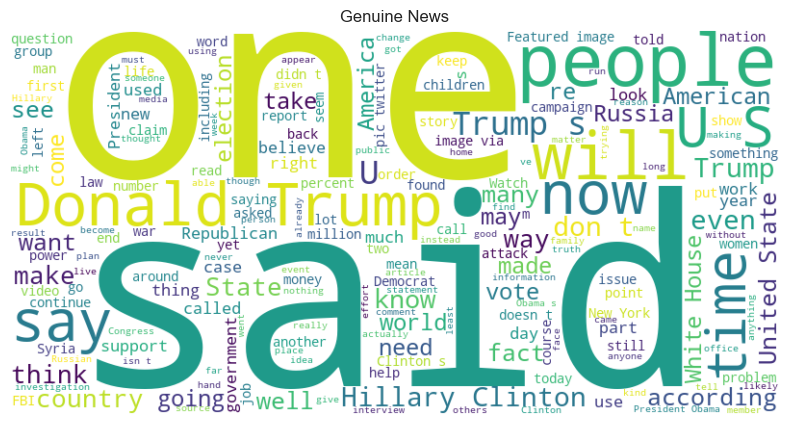

In [19]:
plot_wordcloud(real_text, 'Genuine News')

In [20]:
text_column = 'text'
label_column = 'label'


In [23]:
english_stopwords = set(stopwords.words('english'))
english_stopwords

LookupError: 
**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - '/Users/syrassaladin/nltk_data'
    - '/Users/syrassaladin/PyCharmMiscProject/.venv/nltk_data'
    - '/Users/syrassaladin/PyCharmMiscProject/.venv/share/nltk_data'
    - '/Users/syrassaladin/PyCharmMiscProject/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [24]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


False

In [25]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/syrassaladin/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/syrassaladin/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/syrassaladin/nltk_data...


True

In [26]:
english_stopwords = set(stopwords.words('english'))
english_stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [27]:
english_stopwords.fileids()

AttributeError: 'set' object has no attribute 'fileids'

In [28]:

stopwords.fileids()


['albanian',
 'arabic',
 'azerbaijani',
 'basque',
 'belarusian',
 'bengali',
 'catalan',
 'chinese',
 'danish',
 'dutch',
 'english',
 'finnish',
 'french',
 'german',
 'greek',
 'hebrew',
 'hinglish',
 'hungarian',
 'indonesian',
 'italian',
 'kazakh',
 'nepali',
 'norwegian',
 'portuguese',
 'romanian',
 'russian',
 'slovene',
 'spanish',
 'swedish',
 'tajik',
 'tamil',
 'turkish',
 'uzbek']

In [29]:
def preprocess_text(text):

    #remove punctuation
    remove_punc = [char for char in text if char not in english_punctuation]
    clean_text = ''.join(remove_punc)

    #remove stopwords
    words = clean_text.split()
    text = ' '.join([word for word in words if word.lower() not in english_stopwords])

    return text

In [31]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [32]:
data[text_column] = data[text_column].apply(preprocess_text)
data[text_column].head()

NameError: name 'english_punctuation' is not defined

In [33]:
import string
english_punctuation = string.punctuation
english_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [34]:
data[text_column] = data[text_column].apply(preprocess_text)
data[text_column].head()

0    comment expected Barack Obama Members FYF911 F...
1                           post votes Hillary already
2    demonstrators gathered last night exercising c...
3    dozen politically active pastors came private ...
4    RS28 Sarmat missile dubbed Satan 2 replace SS1...
Name: text, dtype: str

In [35]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    lemmatized_text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

    return lemmatized_text

In [36]:
data[text_column] = data[text_column].apply(lemmatize_text)
data[text_column].head()

0    comment expected Barack Obama Members FYF911 F...
1                            post vote Hillary already
2    demonstrator gathered last night exercising co...
3    dozen politically active pastor came private d...
4    RS28 Sarmat missile dubbed Satan 2 replace SS1...
Name: text, dtype: str

In [37]:
vectorizer = TfidfVectorizer()

x = vectorizer.fit_transform(data[text_column]) #fit ONLY on train
y= data[label_column]

In [38]:
xtrain,xtest,ytrain,ytest = train_test_split(x,labels,test_size=0.3,random_state=42)

In [39]:
xtrain

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10353239 stored elements and shape (50493, 363127)>

In [40]:
def evaluate_model(model, xtest, ytest):
    y_pred = model.predict(xtest)
    accuracy = accuracy_score(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)
    prob = model.predict_proba(xtest)[:, 1]
    roc_auc = roc_auc_score(ytest, prob)
    fpr, tpr, thresholds = roc_curve(ytest, prob)
    precision, recall, _ = precision_recall_curve(ytest, prob)
    pr_auc = auc(recall, precision)

    return {
        'Accuracy': accuracy,
        'Confusion Matrix': cm,
    }

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report, precision_recall_curve, auc


In [44]:
# Multinomial Naive Bayes
mnb_model = MultinomialNB(alpha=1.0, fit_prior=True, class_prior=None)
mnb_model.fit(xtrain, ytrain)

# Evaluate
nb_results = evaluate_model(mnb_model, xtest, ytest)
nb_results

{'Accuracy': 0.8766692851531814,
 'Confusion Matrix': array([[9713,  900],
        [1769, 9259]])}

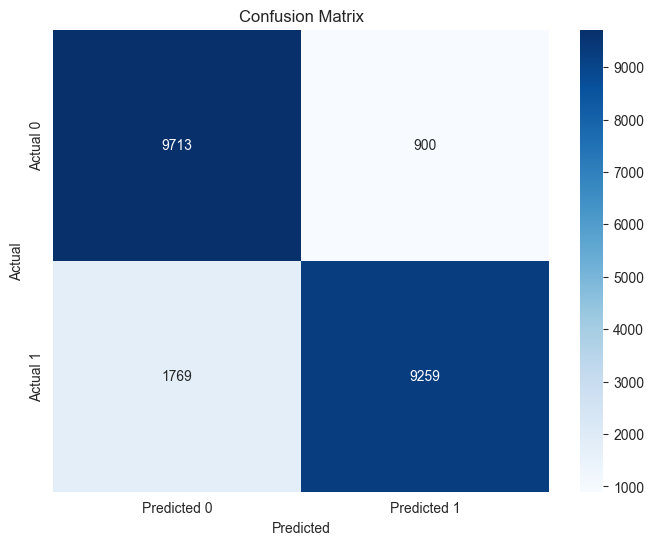

In [45]:
# Evaluate Manually
cm = confusion_matrix(ytest, mnb_model.predict(xtest))
cm

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.85      0.92      0.88     10613
           1       0.91      0.84      0.87     11028

    accuracy                           0.88     21641
   macro avg       0.88      0.88      0.88     21641
weighted avg       0.88      0.88      0.88     21641



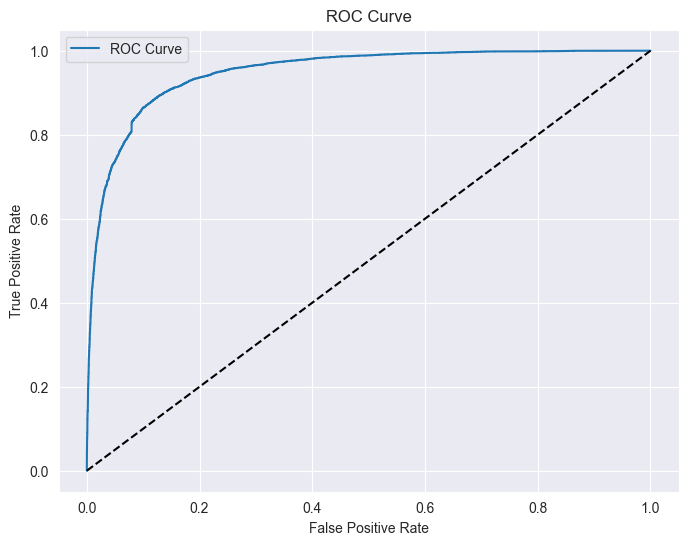

In [46]:
# Classification Report
print(classification_report(ytest, mnb_model.predict(xtest)))

# ROC Curve
prob = mnb_model.predict_proba(xtest)[:, 1]
fpr, tpr, _ = roc_curve(ytest, prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

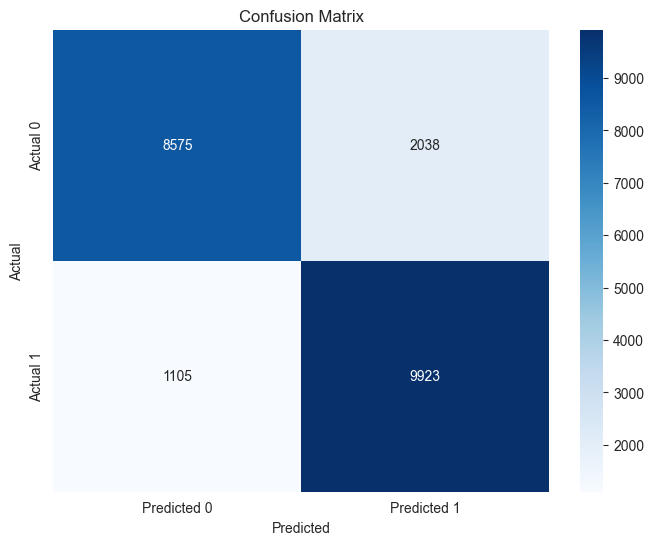

              precision    recall  f1-score   support

           0       0.89      0.81      0.85     10613
           1       0.83      0.90      0.86     11028

    accuracy                           0.85     21641
   macro avg       0.86      0.85      0.85     21641
weighted avg       0.86      0.85      0.85     21641



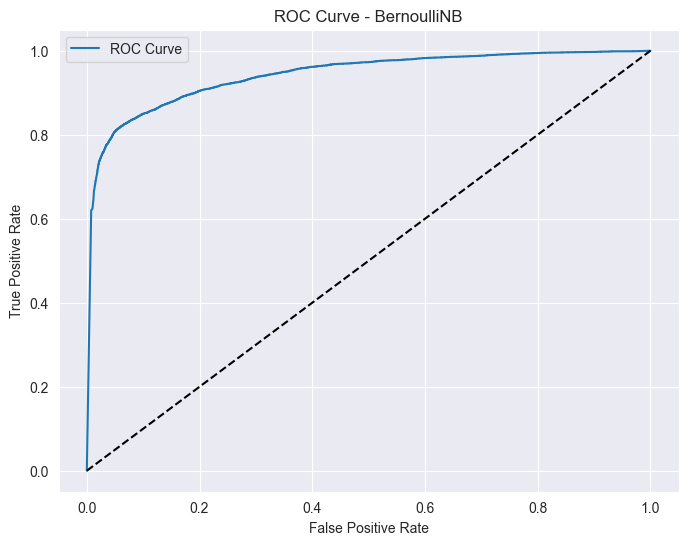

In [47]:
# Bernoulli Naive Bayes
bnb_model = BernoulliNB(alpha=1.0, binarize=0.0, fit_prior=True, class_prior=None)
bnb_model.fit(xtrain, ytrain)

# Evaluate
bnb_results = evaluate_model(bnb_model, xtest, ytest)
bnb_results

# Confusion Matrix
cm_bnb = confusion_matrix(ytest, bnb_model.predict(xtest))
cm_bnb

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(ytest, bnb_model.predict(xtest)))

# ROC Curve
prob_bnb = bnb_model.predict_proba(xtest)[:, 1]
fpr, tpr, _ = roc_curve(ytest, prob_bnb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BernoulliNB')
plt.legend()
plt.show()

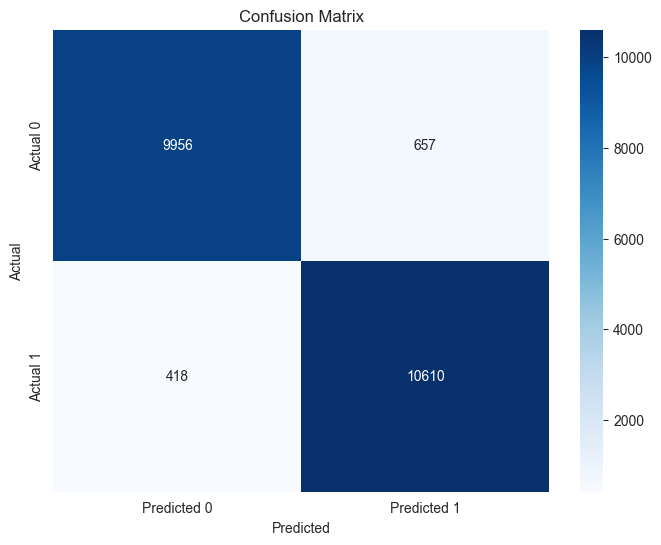

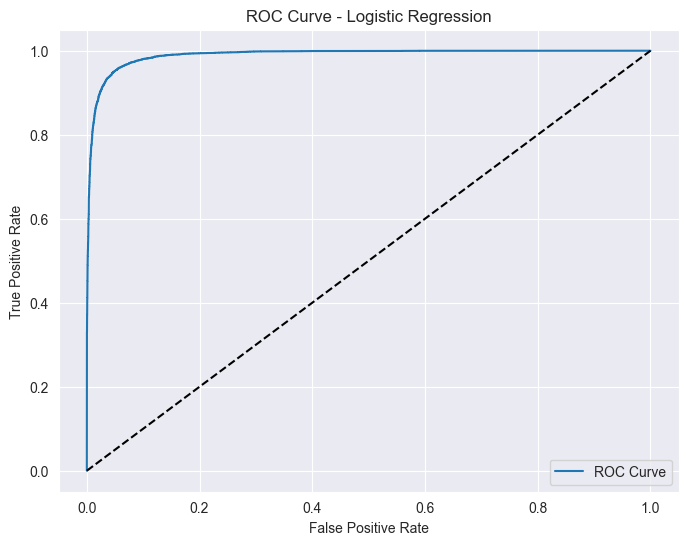

In [48]:
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(xtrain, ytrain)

# Step 12: Evaluate Logistic Regression
lr_results = evaluate_model(lr_model, xtest, ytest)
lr_results

# Confusion Matrix
cm_lr = confusion_matrix(ytest, lr_model.predict(xtest))
cm_lr

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
prob_lr = lr_model.predict_proba(xtest)[:, 1]
fpr, tpr, _ = roc_curve(ytest, prob_lr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

In [49]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(xtrain, ytrain)

# Step 12: Evaluate Logistic Regression
lr_results = evaluate_model(lr_model, xtest, ytest)
lr_results


{'Accuracy': 0.9503257705281641,
 'Confusion Matrix': array([[ 9956,   657],
        [  418, 10610]])}

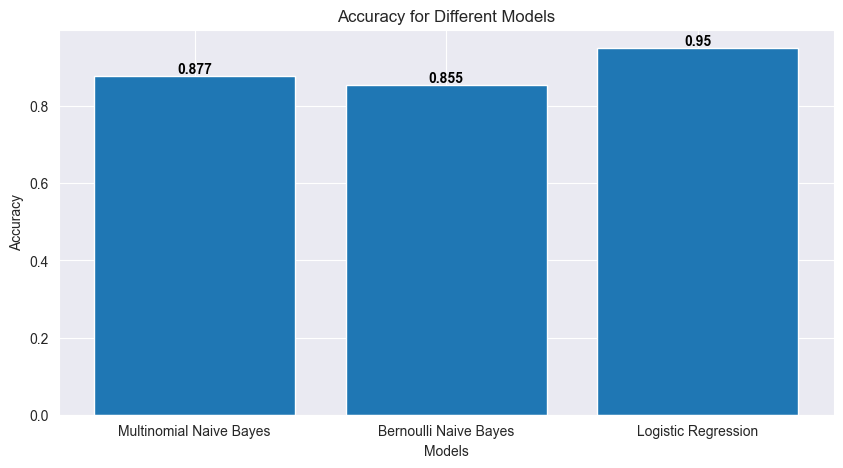

In [50]:
def plot_histogram(metric_values, model_names, metric_name):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = plt.bar(model_names, metric_values)
    plt.xlabel('Models')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} for Different Models')

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom', color='black', fontweight='bold')

    plt.show()

accuracy_values = [nb_results['Accuracy'], bnb_results['Accuracy'], lr_results['Accuracy']]
model_names = ['Multinomial Naive Bayes', 'Bernoulli Naive Bayes', 'Logistic Regression']
plot_histogram(accuracy_values, model_names, 'Accuracy')

In [53]:
# Step 14: Input random text and make a prediction
models = [mnb_model, bnb_model, lr_model]
random_text = input()

preprocessed_text = preprocess_text(random_text)  # remove punctuation
lemmatized_text = lemmatize_text(preprocessed_text)  # text scaling
text_vector = vectorizer.transform([lemmatized_text])

preprocessed_text

lemmatized_text

text_vector

text_vector.toarray()

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 363127))

In [54]:
odels = [mnb_model, bnb_model, lr_model]
random_text = input()

preprocessed_text = preprocess_text(random_text)  # remove punctuation
lemmatized_text = lemmatize_text(preprocessed_text)  #
text_vector = vectorizer.transform([lemmatized_text])

In [55]:
preprocessed_text

lemmatized_text

text_vector

text_vector.toarray()

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 363127))

In [56]:
for model in models:
    prediction = model.predict(text_vector)
    print(f"Model: {type(model).__name__}")
    print("Prediction:", prediction)
    print('\n')

Model: MultinomialNB
Prediction: [1]


Model: BernoulliNB
Prediction: [1]


Model: LogisticRegression
Prediction: [1]




In [57]:
# Step 16: Save Good ML Model for Deployment
import pickle

# Define a file path where you want to save the model
model_file_path = 'logistic_regression_model.pkl'

# Save the model to the file
with open(model_file_path, 'wb') as model_file:
    pickle.dump(lr_model, model_file)

In [60]:
# Save Multinomial Naive Bayes Model
mnb_file_path = 'multinomial_nb_model.pkl'
with open(mnb_file_path, 'wb') as model_file:
    pickle.dump(mnb_model, model_file)

# Save Bernoulli Naive Bayes Model
bnb_file_path = 'bernoulli_nb_model.pkl'
with open(bnb_file_path, 'wb') as model_file:
    pickle.dump(bnb_model, model_file)

In [61]:
# Load Model
with open(model_file_path, 'rb') as model_file:
    loaded_LR = pickle.load(model_file)

loaded_LR.predict(xtest)

loaded_LR.score(xtest, ytest)

text_vector

loaded_LR.predict(text_vector)

array([1])

In [62]:
loaded_LR.score(xtest, ytest)

0.9503257705281641